In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


features: torch.Size([1024, 196])


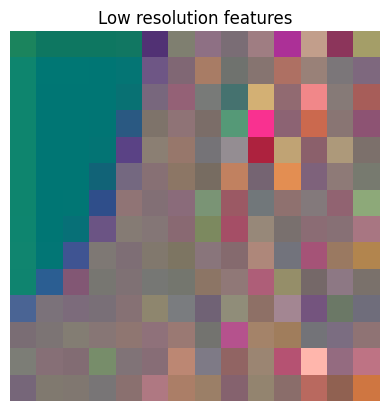

In [41]:
dataset = "apex"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init_n, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")

plots.plot_pca_features(features, title='Low resolution features')

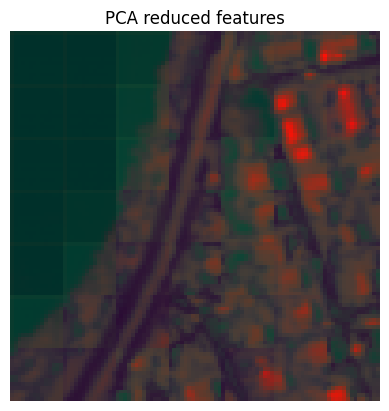

In [42]:
def patch_up_feat_batched(Y_init, alpha, fm, new_H, wavelengths, D, batch_size=8):
    C, H, _ = Y_init.shape
    patch_size = alpha
    n_patches = H // patch_size
    n = n_patches * patch_size
    num_patches = n_patches**2
    features_up = torch.zeros(D, n, n, device=Y_init.device)

    # Extract all patches
    unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
    Y_init_4d = Y_init.unsqueeze(0)
    patches = unfold(Y_init_4d).view(1, C, patch_size, patch_size, -1).permute(0, 4, 1, 2, 3).squeeze(0)

    # Process in batches
    with torch.no_grad():
        for batch_start in range(0, num_patches, batch_size):
            batch_end = min(batch_start + batch_size, num_patches)
            batch_patches = patches[batch_start:batch_end]
            batch_patches_up = F.interpolate(batch_patches, size=(224, 224), mode='bilinear')#, align_corners=False)

            _, batch_features = rsfm.extract_f(fm, batch_patches_up, new_H, wavelengths)
            batch_features = utils.standardise(batch_features)
            # batch_features = batch_features + torch.abs(batch_features.min())
            # batch_features = batch_features/ batch_features.max()

            if batch_features.dim() > 2:
                batch_features = batch_features.permute(2,0,1)
                batch_features = torch.stack([utils.oneD_to_2d(f) for f in batch_features])
            else:
                batch_features = utils.oneD_to_2d(batch_features)

            # Assign to output
            for k in range(batch_end - batch_start):
                patch_idx = batch_start + k
                i = (patch_idx // n_patches) * patch_size
                j = (patch_idx % n_patches) * patch_size
                features_up[:, i:i+patch_size, j:j+patch_size] = batch_features[k]

            del batch_patches, batch_patches_up, batch_features
            torch.cuda.empty_cache()

    return features_up
features_up = patch_up_feat_batched(Y_init_n.squeeze(0), alpha, fm, new_H, wavelengths, D, batch_size=64)
plots.plot_pca_features(features_up)

In [43]:
# def patch_up_feat(Y_init, alpha):
#     patch_size = alpha
#     n_patches = Y_init.shape[-1]//patch_size
#     n = n_patches*patch_size
#     features_up = torch.zeros(D, n, n)

#     with torch.no_grad():
#         for i in range(0,n,patch_size):
#             for j in range(0,n,patch_size):
#                 patch = Y_init[:,:,i:i+patch_size, j:j+patch_size]
#                 patch = F.interpolate(patch, size=(224,224), mode="bilinear")
#                 _, f = rsfm.extract_f(fm, patch, new_H, wavelengths)
#                 f = utils.oneD_to_2d(f)

#                 features_up[:, i:i+patch_size, j:j+patch_size] = f

#                 del f, patch
#                 torch.cuda.empty_cache()
#     return features_up

# features_up = patch_up_feat(Y_init_n, alpha)
# plots.plot_pca_features(features_up, title="patch upsampled features")

In [44]:
# from mpl_toolkits.axes_grid1 import ImageGrid

# patch_size = alpha
# unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
# Y_init_patch = unfold(Y_init_n)
# Y_init_patch = Y_init_patch.view(1, B, patch_size, patch_size, -1).permute(0, 4, 1, 2, 3)
# # Y_init_patch = F.interpolate(Y_init_patch, size=(224, 224), mode='bilinear', align_corners=False).permute(1,0,2,3).unsqueeze(0)

# plt.imshow(Y_init[0,0].detach().cpu())
# plt.show()
# fig = plt.figure(figsize=(8, 8))
# grid = ImageGrid(fig, 111, nrows_ncols=(H//patch_size, H//patch_size), axes_pad=0.01)

# for i, ax in enumerate(grid):
#     patch = Y_init_patch[0, i].detach().cpu() 
#     ax.imshow(patch[0, :,:])
#     ax.axis('off')

# plt.show()

In [45]:
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224):
        """
        Upsamples low res features then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi

        """
        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.B = B
        self.c = c
        self.H = H

        # Upsampled features to abundances
        self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, 1)

        # self.smooth = nn.Sequential(
        #     nn.Conv2d(c, c, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
        #     nn.Softmax(dim=1),
        # )

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Abundances and endmembers regularisation"""
        
        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        """Feature regularisation"""

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse

        if return_losses:
            return loss, loss_sad, loss_ab, loss_tv_e, loss_mse
        else:
            return loss

    def get_abundances(self, features):

        features = features.view(
            1, self.D, self.H, self.H
        )
        features = (features - features.mean())/ (1e-8 + features.std())
        A_hat = self.abundance_estimator(features)
        # A_hat = self.smooth(A_hat)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, Y):
        A_hat = self.get_abundances(Y)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

In [46]:
features.shape

torch.Size([1024, 196])

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.094, NMSE = 0.146
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.098, NMSE = 0.107
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.098, NMSE = 0.091
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.091, NMSE = 0.104
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.094, NMSE = 0.117
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.095, NMSE = 0.084
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.095, NMSE = 0.122

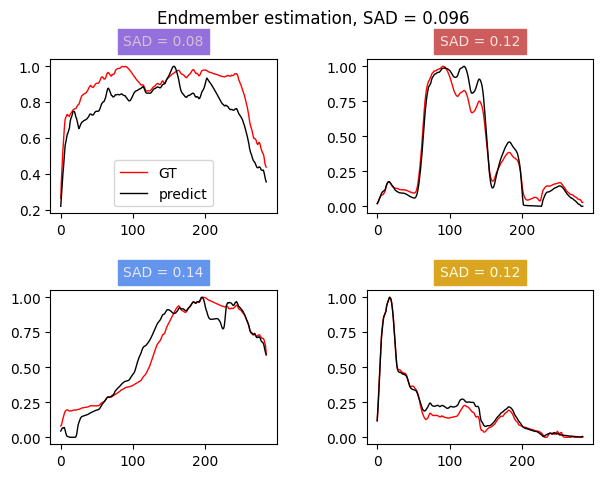

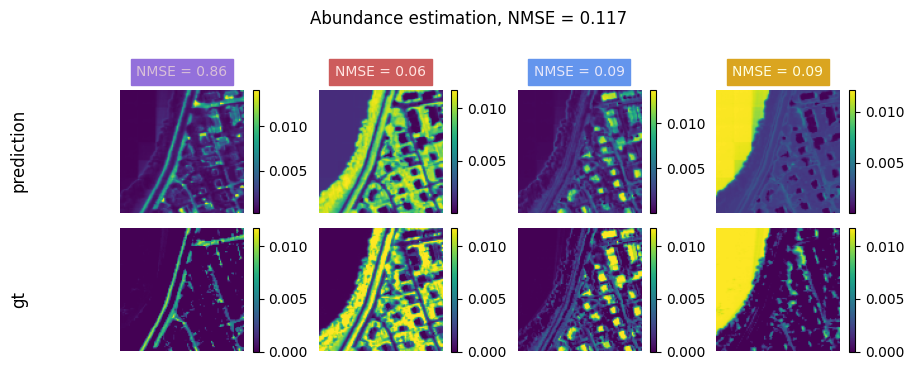

In [47]:
"""Linear upsampling of feature"""

n_xp = 10
mses, sads = [], []
features = patch_up_feat_batched(Y_init.squeeze(0), alpha, fm, new_H, wavelengths, D, batch_size=32)
H_feat = features.shape[-1]
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, H_feat, H_feat)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures(D=D, H=H_feat, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            Y = Y[:, :, :H_feat, :H_feat]

            E_hat, A_hat, Y_hat = model(features)

            loss = model.loss(Y, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        
        A_init_fm = A_init[:,:,:H_feat, :H_feat]
        E_hat, A_hat, _ = model(features)

        if E_hat.isnan().any():
            break
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.nanmean(E_hats, dim=0)
A_hat_m = torch.nanmean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

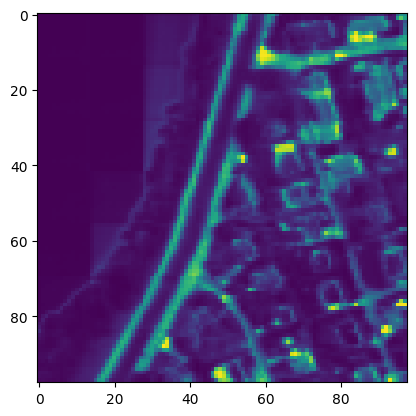

In [48]:
plt.imshow(A_hat_m[0].detach().cpu())
plt.show()
# plt.imshow(A_init[0, 0].detach().cpu())
# plt.axis("off")
# plt.colorbar()